## Forced 3D RMHD turbulence (64^3)

This is the 3D counterpart of `forced-turbulence-2D.ipynb`, testing the Ornstein-Uhlenbeck
forcing scheme (`physics/shared_physics.py::ou_update`, `physics/rmhd.py::ForcingTerm`) at
`dims=3`, resolution 64^3.

We use `forcing_mode="elsasser"` (forces z+ = phi+psi and z- = phi-psi independently, each
at its own target power via `forcing_power_elsasser=(eps_plus, eps_minus)`), matching the 2D
example. Note the caveat from the 2D notebook about `"momentum"`-mode forcing leaving psi
exactly zero **does not apply in 3D**: `LinearTerm` (`physics/rmhd.py`) couples phi and psi
through the parallel (z) derivative (`df_dz_rmhd = [dpsi/dz, dphi/dz]`) whenever
`spatial_dimensions==3`, so psi picks up a source term from phi even before any nonlinear
bracket term kicks in. `"elsasser"` is used here anyway for consistency with the 2D example
and because it exercises both forcing branches (and the `n_ou=2` forcing_state axis) at once.

This run is single-process (no `mpirun`), so the z-domain is not decomposed and
`params.size==1` throughout.

**Diagnostics review:** while building this notebook, `jax_rmhd/diagnostics.py` was reviewed
per the project instructions (the file has/had a `# THESE ARE LIKELY BROKEN` comment at the
top). Findings and fixes:
- `parspec` accessed `state.fields.phik`/`.psik` -- `fields` is a bare array
  (`(nfields, nz_local, nkx, nky)`), not a namedtuple with those attributes; this raised
  `AttributeError` on any call. Fixed to `state.fields[0]`/`[1]`, matching `perpspec` and the
  rest of the codebase. Also added an explicit `assert params.size == 1`: the FFT along z it
  does is local-only (no cross-rank gather), so it silently gives a wrong answer under domain
  decomposition -- better to fail loudly. This notebook is single-process, so it's exercised
  correctly here (see the "Parallel (z) spectrum" section below).
- `energy` called `from .physics import gradk`, but `gradk` is only exported from
  `physics.shared_physics`, not `physics/__init__.py` -- `ImportError` on any call. Also called
  `grids.ifft(gfk)` with the wrong arity (`ifft` takes `(f, params)`) inside a
  `jax.tree_util.tree_map`, which is a no-op here since `gradk(...)` returns a single stacked
  array (a single pytree leaf), not a container -- `tree_map` was doing nothing useful. Fixed
  the import, the `ifft` call, dropped the pointless `tree_map`, and fixed `fields.phik`/`.psik`
  the same way as `parspec`. Not used below (`shared_physics.perp_inner_product` is preferred,
  see the 2D example), but now at least callable and dimensionally consistent.
- `perpspec` had no correctness bug, but silently assumed a single z-rank: it summed over the
  local z-slab and divided by the *global* `params.nz`, which undercounts whenever the z-domain
  is decomposed across ranks. Added the same allreduce-across-`cart_comm` pattern used by
  `shared_physics._perp_reduce`, so it's now correct for `params.size > 1` too (not exercised in
  this single-process notebook, but relevant for real multi-rank 3D runs).


In [1]:
#imports
import os
import jax
import jax_rmhd as jr
import jax.numpy as jnp
import jax.numpy.fft as ft
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.colors as colors

import jax_rmhd.snapshot_io as sn
import jax_rmhd.diagnostics as diag
#lower-level helper reused here for a total-energy diagnostic in the same physical units
#that forcing_power is defined in (see physics/shared_physics.py)
from jax_rmhd.physics import shared_physics

jr.init_cluster()


jax is using 64bit precision.


In [2]:
#grid + physical parameters
nx = 64
ny = 64
nz = 64
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
Lz = 2.0 * jnp.pi

nsnap = 100
t_snap = 0.25
t_end = 5.0
cfl_safety = 0.5
spatial_dimensions = 3
snap_path = "data/forced-turbulence-3D/"

#hyperviscosity; 64^3 is coarser than the 256^2 2D example, so a stronger (lower hyper-order,
#larger coefficient) dissipation is used to keep the grid-scale cascade under control -- tune
#if the run looks under- or over-dissipated in the spectra below.
visc = 1e-5
res = 1e-5
hyper = 3

#forcing parameters
forcing = True
forcing_mode = "elsasser"
forcing_power_elsasser = (0.3, 0.3)   #target energy injection rate, one per Elsasser variable
forcing_tau = 1.0                      #O-U decorrelation time of the forcing pattern
fshell = (1, 3)                        #force the shell 1 <= |k_perp|/dk < 3 (large scales)
forcing_seed = 42                      # random seed
forcing_scale_max = 1.0                #caps the energy added per timestep


params = jr.Parameters(nx=nx, ny=ny, Lx=Lx, Ly=Ly, nz=nz, Lz=Lz, diss=(visc, res),
                        hyper=hyper, cfl_safety=cfl_safety, dims=spatial_dimensions,
                        forcing=forcing, forcing_mode=forcing_mode, forcing_power_elsasser=forcing_power_elsasser,
                        forcing_tau=forcing_tau, fshell=fshell, forcing_seed=forcing_seed,
                        forcing_scale_max=forcing_scale_max)

print(f"params.size={params.size} (single-process run -- z-domain is not decomposed)")

mngr = jr.snapshot_manager_setup(params=params, snap_path=snap_path, nsnap=nsnap)

kgrid = jr.setup_kgrids(params)


params.size=1 (single-process run -- z-domain is not decomposed)


### Initial condition

Start from a quiescent plasma (all fields zero) and let the forcing spin up turbulence
from rest, same as the 2D example -- no need to seed any structure by hand. The 3D init
function additionally takes `z`, per `run.py::initialize`.


In [3]:
def zero_init(x, y, z):
    return jnp.zeros((2,) + jnp.broadcast_shapes(x.shape, y.shape, z.shape))

state = jr.initialize(zero_init, params)
print("fields shape:", state.fields.shape)  # (nfields, nz_local, nkx, nky)

nblock = jr.estimate_good_nblock(state, kgrid, params, t_snap, t_end, nblock_min=10)
print("nblock estimate: " + str(nblock))


fields shape: (2, 64, 64, 33)
nblock estimate: 10


In [4]:
#run the simulation, saving snapshots along the way
end_state = jr.simulate_scan(state, kgrid, params, nblock, t_snap=t_snap, t_end=t_end,
                              mngr=mngr, save=True)


Saving initial state as snapshot 0
0.477012810013667
Saving snapshot 1
0.7742610056299962
Saving snapshot 2
0.9916025532724183
1.1759912763429732
Saving snapshot 3
1.3413787457037738
1.499462630440622
Saving snapshot 4
1.6583265973097563
1.8144126354974017
Saving snapshot 5
1.9699358975475139
2.1264724347020527
Saving snapshot 6
2.2760668164912965
2.4226336365997456
Saving snapshot 7
2.5706929825104896
2.7257307427289925
Saving snapshot 8
2.8776008653333065
3.022336363500433
Saving snapshot 9
3.160179926700831
3.2909857308482318
Saving snapshot 10
3.418832221357573
3.546356954795438
Saving snapshot 11
3.6766066380262927
3.8069903913273406
Saving snapshot 12
3.9348134903139877
4.052702740043454
4.1650612403673035
Saving snapshot 13
4.275850328623862
4.388297802637635
4.502230363650442
Saving snapshot 14
4.620147491791237
4.736655610623544
4.852440409494686
Saving snapshot 15
4.9669445158223295
5.0819517544955755
Saving final state as snapshot 16
Ending simulation at t = 5.08195175449557

In [5]:
#this is just to check that the snapshots save and load correctly, including the key (which is some weird jax object)

last_isnap = max(mngr.all_steps())
print(f"Reloading snapshot {last_isnap} and comparing against the in-memory end_state...")
reloaded = sn.load_snapshot(last_isnap, snap_path, params)

t_diff = float(jnp.abs(reloaded.t - end_state.t))
fields_diff = float(jnp.max(jnp.abs(reloaded.fields - end_state.fields)))
forcing_state_diff = float(jnp.max(jnp.abs(reloaded.forcing_state - end_state.forcing_state)))
key_match = bool(jnp.array_equal(jax.random.key_data(reloaded.forcing_key),
                                  jax.random.key_data(end_state.forcing_key)))

print(f"  t:                        reloaded={float(reloaded.t):.6f}, end_state={float(end_state.t):.6f}, diff={t_diff:.3e}")
print(f"  fields max abs diff:      {fields_diff:.3e}")
print(f"  forcing_state max abs diff: {forcing_state_diff:.3e}")
print(f"  forcing_key matches:      {key_match}")

ok = (t_diff < 1e-8) and (fields_diff < 1e-8) and (forcing_state_diff < 1e-8) and key_match
print()
print("PASS: reloaded snapshot matches the in-memory end_state" if ok
      else "FAIL: reloaded snapshot does NOT match the in-memory end_state")


Reloading snapshot 16 and comparing against the in-memory end_state...
  t:                        reloaded=5.081952, end_state=5.081952, diff=0.000e+00
  fields max abs diff:      0.000e+00
  forcing_state max abs diff: 0.000e+00
  forcing_key matches:      True

PASS: reloaded snapshot matches the in-memory end_state


### Vorticity: 3-face cube plot

Same approach as `examples/3d_image.ipynb` (three visible cube faces colored by the
perpendicular vorticity $\zeta = \nabla_\perp^2 \phi$, `plot_surface` with `facecolors`),
refactored into a reusable function and updated to the current field API: the original
notebook indexes `snap.fields.phik`/calls `jr.setup_sharding(params)`, both of which predate
the current `fields[i]` array API and `jr.__init__`'s exports (`setup_sharding` isn't
exported at all any more) -- per `CLAUDE.md`, `3d_image.ipynb` is one of the stale examples
that "will error as-is".


In [6]:
def plot_vorticity_cube(vort, L, title=None, vscale=None):
    """3-face cube plot of a real-space 3D field, e.g. vorticity, shape (nz,nx,ny).
    Adapted from examples/3d_image.ipynb."""
    data = np.asarray(vort)
    N = data.shape[0]
    if vscale is None:
        vscale = float(np.max(np.abs(data)))
    norm = colors.Normalize(vmin=-vscale, vmax=vscale)
    color_data_XY = cm.afmhot(norm(data[N-1, :, :]))
    color_data_XZ = cm.afmhot(norm(data[:, :, N-1]))
    color_data_YZ = cm.afmhot(norm(data[:, N-1, :]))

    coords = np.linspace(0, L, N)
    X, Y = np.meshgrid(coords, coords, indexing='ij')

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(np.full_like(X, L), X, Y, facecolors=color_data_XY, shade=False, rstride=1, cstride=1)
    ax.plot_surface(X, np.full_like(X, L), Y, facecolors=color_data_YZ, shade=False, rstride=1, cstride=1)
    ax.plot_surface(X, Y, np.full_like(X, L), facecolors=color_data_XZ, shade=False, rstride=1, cstride=1)

    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_zlim(0, L)
    ax.view_init(elev=30, azim=45)
    ax.set_axis_off()

    edges = [
        ([0, L], [L, L], [L, L]), ([0, L], [0, 0], [L, L]), ([0, L], [L, L], [0, 0]),
        ([0, 0], [0, L], [L, L]), ([L, L], [0, L], [0, 0]), ([L, L], [0, L], [L, L]),
        ([L, L], [0, 0], [0, L]), ([L, L], [L, L], [0, L]), ([0, 0], [L, L], [0, L]),
    ]
    for xe, ye, ze in edges:
        ax.plot(xe, ye, ze, 'k', linewidth=1, zorder=10)

    if title:
        ax.set_title(title)
    return fig, ax


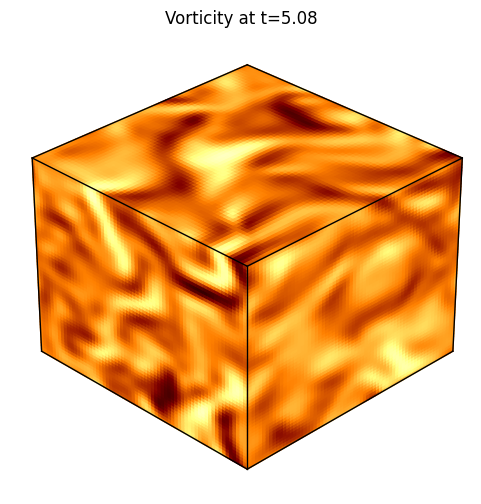

In [7]:
vort = ft.irfft2(-kgrid.ksq() * end_state.fields[0])   # (nz, nx, ny), real-space vorticity
vort = jnp.roll(vort, params.nz // 2, axis=0)           # center the box, matching 3d_image.ipynb

fig, ax = plot_vorticity_cube(vort, float(params.Lx), title=f"Vorticity at t={float(end_state.t):.2f}")
plt.show()


### Perpendicular energy spectrum

Same as the 2D example (`diag.perpspec`, z-averaged). Dashed vertical lines mark the
forcing shell (`fshell`).


Text(0.5, 1.0, 'Perpendicular spectrum at t=5.08')

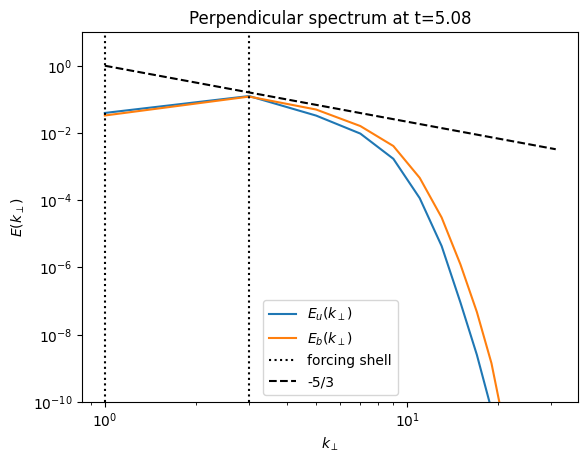

In [8]:
bins, su, sb = diag.perpspec(end_state, kgrid, params)

plt.loglog(bins, su, label=r'$E_u(k_\perp)$')
plt.loglog(bins, sb, label=r'$E_b(k_\perp)$')
kunit = min(2*jnp.pi/params.Lx, 2*jnp.pi/params.Ly)
plt.axvline(params.fshell[0]*kunit, color='k', linestyle=':', label='forcing shell')
plt.axvline(params.fshell[1]*kunit, color='k', linestyle=':')
plt.loglog(bins, bins**-(5./3.), 'k--', label='-5/3')
plt.xlabel(r'$k_\perp$')
plt.ylabel(r'$E(k_\perp)$')
plt.ylim(1e-10, 10)
plt.legend()
plt.title(f"Perpendicular spectrum at t={float(end_state.t):.2f}")


### Parallel (z) energy spectrum

3D-specific diagnostic: `diag.parspec`, the kz-analog of `perpspec`. This exercises the
`parspec` fix described above -- it would previously have raised `AttributeError`
(`state.fields.phik`) on the very first call.


Text(0.5, 1.0, 'Parallel spectrum at t=5.08')

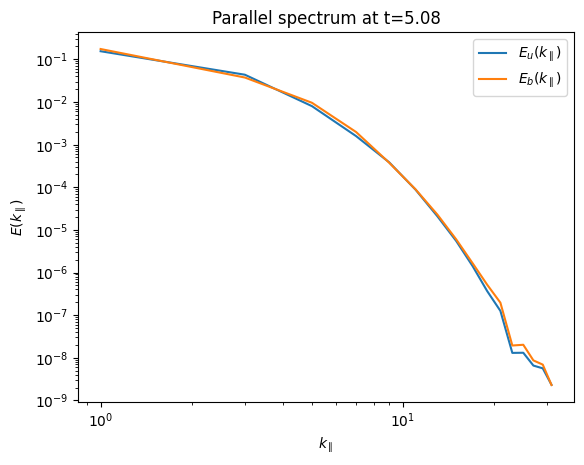

In [9]:
binsz, suz, sbz = diag.parspec(end_state, kgrid, params)

plt.loglog(binsz, suz, label=r'$E_u(k_\parallel)$')
plt.loglog(binsz, sbz, label=r'$E_b(k_\parallel)$')
plt.xlabel(r'$k_\parallel$')
plt.ylabel(r'$E(k_\parallel)$')
plt.legend()
plt.title(f"Parallel spectrum at t={float(end_state.t):.2f}")


### Diagnostics vs time

Same approach as the 2D example: `shared_physics.perp_inner_product`/`perp_mean_square`
directly on the saved snapshots, rather than `diag.energy` (kept only as a real-space cross
check -- see the note at the top -- and not MPI-aware, unlike `perp_inner_product`).


In [10]:
ts = []
E_kin_list = []
E_mag_list = []
psi_sq_list = []
for isnap in sorted(mngr.all_steps()):
    snap = sn.load_snapshot(isnap, snap_path, params)
    phik, psik = snap.fields[0], snap.fields[1]
    E_kin = 0.5*shared_physics.perp_inner_product(phik, phik, kgrid, params)
    E_mag = 0.5*shared_physics.perp_inner_product(psik, psik, kgrid, params)
    psi_sq = shared_physics.perp_mean_square(psik, psik, kgrid, params)
    ts.append(float(snap.t))
    E_kin_list.append(float(E_kin))
    E_mag_list.append(float(E_mag))
    psi_sq_list.append(float(psi_sq))


### Kinetic and magnetic energy vs time

Text(0.5, 1.0, 'Kinetic and magnetic energy vs time')

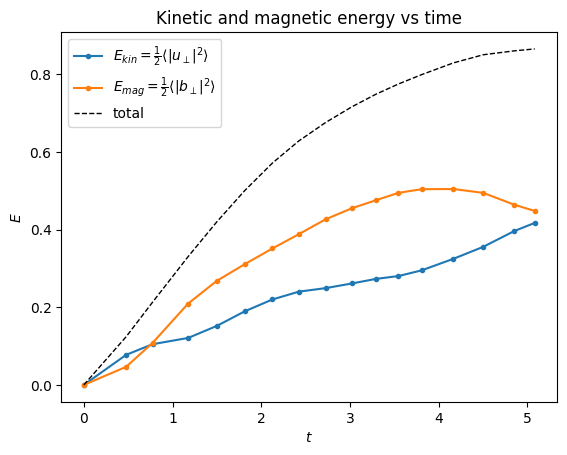

In [11]:
plt.plot(ts, E_kin_list, marker='o', markersize=3, label=r'$E_{kin}=\frac{1}{2}\langle|u_\perp|^2\rangle$')
plt.plot(ts, E_mag_list, marker='o', markersize=3, label=r'$E_{mag}=\frac{1}{2}\langle|b_\perp|^2\rangle$')
plt.plot(ts, [ek + em for ek, em in zip(E_kin_list, E_mag_list)], 'k--', linewidth=1, label='total')
plt.xlabel(r'$t$')
plt.ylabel(r'$E$')
plt.legend()
plt.title("Kinetic and magnetic energy vs time")


### `<psi^2>` vs time

As in the 2D example: mean-square flux function, tracked separately from the (forward-
cascading) energy since it can inverse-cascade to large scales.


Text(0.5, 1.0, 'Mean-square flux function $\\langle\\psi^2\\rangle$ vs time')

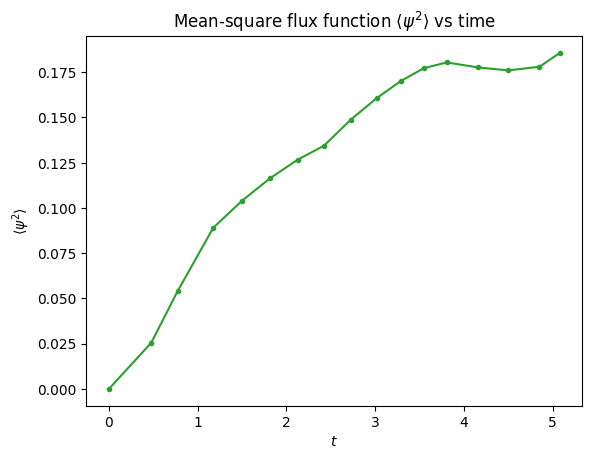

In [12]:
plt.plot(ts, psi_sq_list, marker='o', markersize=3, color='C2')
plt.xlabel(r'$t$')
plt.ylabel(r'$\langle \psi^2 \rangle$')
plt.title(r"Mean-square flux function $\langle\psi^2\rangle$ vs time")


### Vorticity frames across the run

The same routine `3d_image.ipynb` uses: loop over saved snapshots, cube-plot each, save a
PNG. Frame color scale is fixed to the final-state max so frames are comparable across time
(same trick as the 2D example's GIF cell).


In [13]:
gif_frames_dir = os.path.abspath(snap_path + "gif_frames")
os.makedirs(gif_frames_dir, exist_ok=True)

vort_final = ft.irfft2(-kgrid.ksq() * end_state.fields[0])
vort_scale = float(jnp.max(jnp.abs(vort_final)))

all_isnaps = sorted(mngr.all_steps())
for i, isnap in enumerate(all_isnaps):
    snap = sn.load_snapshot(isnap, snap_path, params)
    vort_i = ft.irfft2(-kgrid.ksq() * snap.fields[0])
    vort_i = jnp.roll(vort_i, params.nz // 2, axis=0)

    fig, ax = plot_vorticity_cube(vort_i, float(params.Lx), title=f"Vorticity, t={float(snap.t):.2f}", vscale=vort_scale)
    fig.savefig(os.path.join(gif_frames_dir, str(i).zfill(4) + ".png"))
    plt.close(fig)

print(f"Wrote {len(all_isnaps)} frames to {gif_frames_dir}")


Wrote 17 frames to /Users/alfy/jax_rmhd/examples/data/forced-turbulence-3D/gif_frames


In [ ]:
#optional: assemble frames into a GIF, same as the 2D example (requires ImageMagick's `magick`)
gif_out = os.path.abspath(os.path.join(snap_path, "forced-turbulence-3D.gif"))
os.system(f'magick -delay 15 -loop 0 "{gif_frames_dir}"/*.png "{gif_out}"')
print(f"Wrote GIF to {gif_out}" if os.path.exists(gif_out)
      else "GIF not created -- is ImageMagick (`magick`) installed? Frame PNGs are still in gif_frames_dir.")


Wrote GIF to /Users/alfy/jax_rmhd/examples/data/forced-turbulence-3D/forced-turbulence-3D.gif


: 